In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [49]:

event_logs = pd.read_csv('../raw_datasets/event_logs.csv')
marketing_summary = pd.read_csv('../raw_datasets/marketing_summary.csv')
trend_report = pd.read_csv('../raw_datasets/trend_report.csv')

# Preliminary EDA


In [50]:
for name, df in [('event_logs', event_logs), 
                  ('marketing_summary', marketing_summary), 
                  ('trend_report', trend_report)]:
    print(f"\n{name}:")
    print((df.isnull().mean() * 100).round(1).to_string())


event_logs:
user_id        0.0
event_type     0.0
event_time     0.0
product_id     0.0
amount        50.8
col_6         25.8
col_7         28.8
col_8         28.9
col_9         24.6
col_10        30.8
col_11        29.0
col_12        24.8
col_13        29.7
col_14        29.6
col_15        23.6
col_16        29.6
col_17        29.6
col_18        24.6
col_19        29.7
col_20        30.5
col_21        26.8
col_22        30.2
col_23        28.9
col_24        25.7
col_25        30.6
col_26        29.4
col_27        25.8
col_28        31.0
col_29        30.6
col_30        24.7
col_31        30.0
col_32        30.6
col_33        25.5
col_34        30.4
col_35        29.6
col_36        24.0
col_37        29.6
col_38        31.7
col_39        25.2
col_40        30.6
col_41        30.7
col_42        26.0
col_43        30.0
col_44        31.0
col_45        25.8
col_46        29.6
col_47        30.0
col_48        26.2
col_49        31.4
col_50        31.5

marketing_summary:
date             

In [51]:
raw = {
    'event_logs':        event_logs[['user_id','event_type','event_time','product_id','amount']].isnull().mean() * 100,
    'marketing_summary': marketing_summary[['date','users_active','total_sales','new_customers','report_generated']].isnull().mean() * 100,
    'trend_report':      trend_report[['week','avg_users','sales_growth_rate']].isnull().mean() * 100
}

The following schema check makes sure the pipeline doesn't crash, but a missing critical column means that specific downstream metric is flagged as unusable, not silently treated as valid. 

We will flag those missing columns as Nans to continue the procecss, which will cause problems for forecasting an future graphs, but this is the best solution in this circumstance because the alternative is that the pipeline will crash, or worse,show incorrect findings in our visualization tool. 

This fallback prevents pipeline failure, it does not prevent forecast degradation

Further comments can be found in the string comment below


In [52]:
#Validation log for schema checks as per draft instructions

validation_log = []

def check_schema(df, df_name, required_cols, numeric_cols=None):
    """
    Ensures required_cols exist on df. Missing columns are added
    as all-NaN (fallback) so downstream code doesn't break.
    numeric_cols are sanity-checked for coercibility; failures are
    logged, not fixed here (existing pd.to_numeric(errors='coerce')
    lines still own the actual coercion).
    """
    numeric_cols = numeric_cols or []
    missing = [c for c in required_cols if c not in df.columns]

    for col in missing:
        df[col] = np.nan
        validation_log.append(
            f"[MISSING COLUMN] {df_name}: '{col}' not found in source CSV. "
            f"Created as NaN fallback — any metric/forecast depending on "
            f"'{col}' will be invalid for this run."
        )

    for col in numeric_cols:
        if col in df.columns and col not in missing:
            non_numeric_count = pd.to_numeric(df[col], errors='coerce').isna().sum() - df[col].isna().sum()
            if non_numeric_count > 0:
                validation_log.append(
                    f"[DTYPE WARNING] {df_name}: '{col}' has {non_numeric_count} "
                    f"value(s) that are not numeric-coercible. Existing "
                    f"pd.to_numeric(errors='coerce') will convert these to NaN."
                )
    
    if missing:
        print(f"⚠️  {df_name}: schema issue detected — {missing}. See validation_log.")
    else:
        print(f"✅ {df_name}: schema OK.")

    return df

In [53]:
#event logs

# --- event_logs ---
event_logs = check_schema(
    event_logs, 'event_logs',
    required_cols=['user_id', 'event_type', 'event_time', 'product_id', 'amount'],
    numeric_cols=['amount']
)

# --- marketing_summary ---
marketing_summary = check_schema(
    marketing_summary, 'marketing_summary',
    required_cols=['date', 'users_active', 'total_sales', 'new_customers', 'report_generated'],
    numeric_cols=['users_active', 'total_sales', 'new_customers']
)

# --- trend_report ---
trend_report = check_schema(
    trend_report, 'trend_report',
    required_cols=['week', 'avg_users', 'sales_growth_rate'],
    numeric_cols=['avg_users', 'sales_growth_rate']
)

# Print full log at the end of the validation gate (also useful to
# It is possible to export later as a data-quality report artifact for sir Hernani if it is brought up in reporting)
if validation_log:
    print("\n".join(validation_log))
else:
    print("No schema issues detected across all 3 datasets.")

✅ event_logs: schema OK.
✅ marketing_summary: schema OK.
✅ trend_report: schema OK.
No schema issues detected across all 3 datasets.


# 1. Event Logs

In [54]:
#Remove mess data
event_logs = event_logs[['user_id', 'event_type', 'event_time', 'product_id', 'amount']]
event_logs.head()

,user_id,event_type,event_time,product_id,amount
0,U0099,checkout,2023-06-03 04:13,P010,NaN
1,U0240,wishlist_add,2023-06-03 05:08,P020,2900.63
2,U0374,profile_update,2023-06-05 06:22,P028,NaN
3,U0122,page_view,2023-06-06 03:45,P001,NaN
4,U0211,wishlist_add,2023-06-03 12:38,P015,1728.27


In [55]:
event_logs['product_id'].astype(str).unique()

array(['P010', 'P020', 'P028', 'P001', 'P015', 'P018', 'P006', 'P005',
       'P025', 'P026', 'P029', 'P012', 'P027', 'P007', 'P008', 'P004',
       'P024', 'P014', 'P003', 'P019', 'P011', 'P030', 'P017', 'P013',
       'P022', 'P021', 'P002', 'P023', 'P009', 'P016'], dtype=object)

###  User ID  column

In [56]:
# Normalize 
event_logs['user_id'] = event_logs['user_id'].astype(str).str.strip()

#Validate Structure
event_logs['user_id_valid'] = event_logs['user_id'].notna() & (event_logs['user_id'] != 'nan')

# Flag records with missing IDs
event_logs.loc[~event_logs['user_id_valid'], 'user_id'] = 'unknown_user'

### Event_Time

In [57]:
#normalize
event_logs['event_time'] = pd.to_datetime( event_logs['event_time'], errors='coerce' ) 
#avoid future dates/ invalids 
event_logs.loc[ event_logs['event_time'] > pd.Timestamp.now(), 'event_time' ] = pd.NaT

### Event_Type


In [58]:
#Normalize
event_logs['event_type'] = (
    event_logs['event_type']
    .astype(str)
    .str.strip()
    .str.lower()
)
#Define all taxonomy
valid_events = {
    'checkout',
    'wishlist_add',
    'profile_update',
    'page_view',
    'login',
    'logout',
    'search',
    'add_to_cart'
}
#Validate the event types
event_logs['event_type_valid'] = event_logs['event_type'].isin(valid_events)

#handle unknowns
event_logs.loc[~event_logs['event_type_valid'], 'event_type'] = 'unknown_event'

### Product ID

In [59]:
import re

# Normalize
event_logs['product_id'] = (
    event_logs['product_id']
    .astype(str)
    .str.strip()
    .str.upper()
)

# Validate format
pattern = r'^P\d{3}$'

event_logs['product_id_valid'] = event_logs['product_id'].str.match(pattern)

# Handle invalids
event_logs.loc[~event_logs['product_id_valid'], 'product_id'] = None

### Amount

In [60]:
#normalize dtype 

event_logs['amount'] = pd.to_numeric(event_logs['amount'], errors='coerce')

#turn every row with event type that is not checkout or add to cart as 0
event_logs.loc[
    ~event_logs['event_type'].isin(['checkout', 'add_to_cart']),
    'amount'
] = 0

#detect bad checkout data
event_logs['invalid_checkout_amount'] = (
    (event_logs['event_type'] == 'checkout') &
    (event_logs['amount'].isna() | (event_logs['amount'] == 0))
)

# 2. Marketing Summary 

In [61]:
#Remove mess data

marketing_summary = marketing_summary[['date','users_active','total_sales','new_customers','report_generated']]
marketing_summary.head()


,date,users_active,total_sales,new_customers,report_generated
0,2023-06-01,179,81287.31,9,2023-06-01 16:00
1,2023-06-02,67,74771.99,5,2023-06-02 16:00
2,2023-06-03,369,84809.74,11,2023-06-03 16:00
3,2023-06-04,94,61212.30,3,2023-06-04 16:00
4,2023-06-05,402,80911.49,10,2023-06-05 16:00


### Date

In [62]:
#normalize dtype
marketing_summary['date'] = pd.to_datetime(marketing_summary['date'], errors='coerce')


### users active, new customers and total sales

In [63]:
cols = ['users_active', 'new_customers', 'total_sales']

for col in cols:
    marketing_summary[col] = pd.to_numeric(marketing_summary[col], errors='coerce')
    marketing_summary.loc[marketing_summary[col] < 0, col] = np.nan

### Report Generated

In [64]:
#normalize
marketing_summary['report_generated'] = pd.to_datetime(
    marketing_summary['report_generated'],
    errors='coerce'
)
#avoid future dates/ invalids
marketing_summary.loc[
    marketing_summary['report_generated'] > pd.Timestamp.now(),
    'report_generated'
] = pd.NaT

# 3.Trend Report

In [65]:
#Remove mess data
trend_report = trend_report[['week','avg_users','sales_growth_rate']]
trend_report.head()

,week,avg_users,sales_growth_rate
0,2023-W21,328,-0.003
1,2023-W22,280,0.088
2,2023-W23,130,0.073
3,2023-W24,291,0.077
4,2023-W25,200,-0.003


### week

In [66]:
# normalize
trend_report['week'] = trend_report['week'].astype(str).str.strip()

# convert to datetime (week start)
trend_report['week_start'] = pd.to_datetime(
    trend_report['week'] + '-1',
    format='%Y-W%U-%w',
    errors='coerce'
)

/var/folders/fb/r3xfzh555slbpdxcyfkj672w0000gn/T/ipykernel_4175/2031028760.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trend_report['week'] = trend_report['week'].astype(str).str.strip()
/var/folders/fb/r3xfzh555slbpdxcyfkj672w0000gn/T/ipykernel_4175/2031028760.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trend_report['week_start'] = pd.to_datetime(


In [67]:
trend_report.head()

,week,avg_users,sales_growth_rate,week_start
0,2023-W21,328,-0.003,2023-05-22
1,2023-W22,280,0.088,2023-05-29
2,2023-W23,130,0.073,2023-06-05
3,2023-W24,291,0.077,2023-06-12
4,2023-W25,200,-0.003,2023-06-19


### Avg users

In [68]:
trend_report['avg_users'] = pd.to_numeric(trend_report['avg_users'], errors='coerce')
trend_report.loc[trend_report['avg_users'] < 0, 'avg_users'] = np.nan

/var/folders/fb/r3xfzh555slbpdxcyfkj672w0000gn/T/ipykernel_4175/3113025396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trend_report['avg_users'] = pd.to_numeric(trend_report['avg_users'], errors='coerce')


### Sales Growth Rate'

In [69]:
trend_report['sales_growth_rate'] = pd.to_numeric(trend_report['sales_growth_rate'], errors='coerce')

/var/folders/fb/r3xfzh555slbpdxcyfkj672w0000gn/T/ipykernel_4175/2584217574.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trend_report['sales_growth_rate'] = pd.to_numeric(trend_report['sales_growth_rate'], errors='coerce')


In [70]:

#export verything
event_logs = event_logs.loc[:, :'amount']

event_logs.to_csv('event_logs(1).csv', index=False)
marketing_summary.to_csv('marketing_summary(1).csv', index=False)
trend_report.to_csv('trend_report(1).csv', index=False)

In [71]:
for name, df in [('event_logs', event_logs), 
                  ('marketing_summary', marketing_summary), 
                  ('trend_report', trend_report)]:
    print(f"\n{name}:")
    print((df.isnull().mean() * 100).round(1).to_string())


event_logs:
user_id        0.0
event_type     0.0
event_time     0.0
product_id     0.0
amount        14.0

marketing_summary:
date                0.0
users_active        0.0
total_sales         0.0
new_customers       0.0
report_generated    0.0

trend_report:
week                 0.0
avg_users            0.0
sales_growth_rate    0.0
week_start           0.0


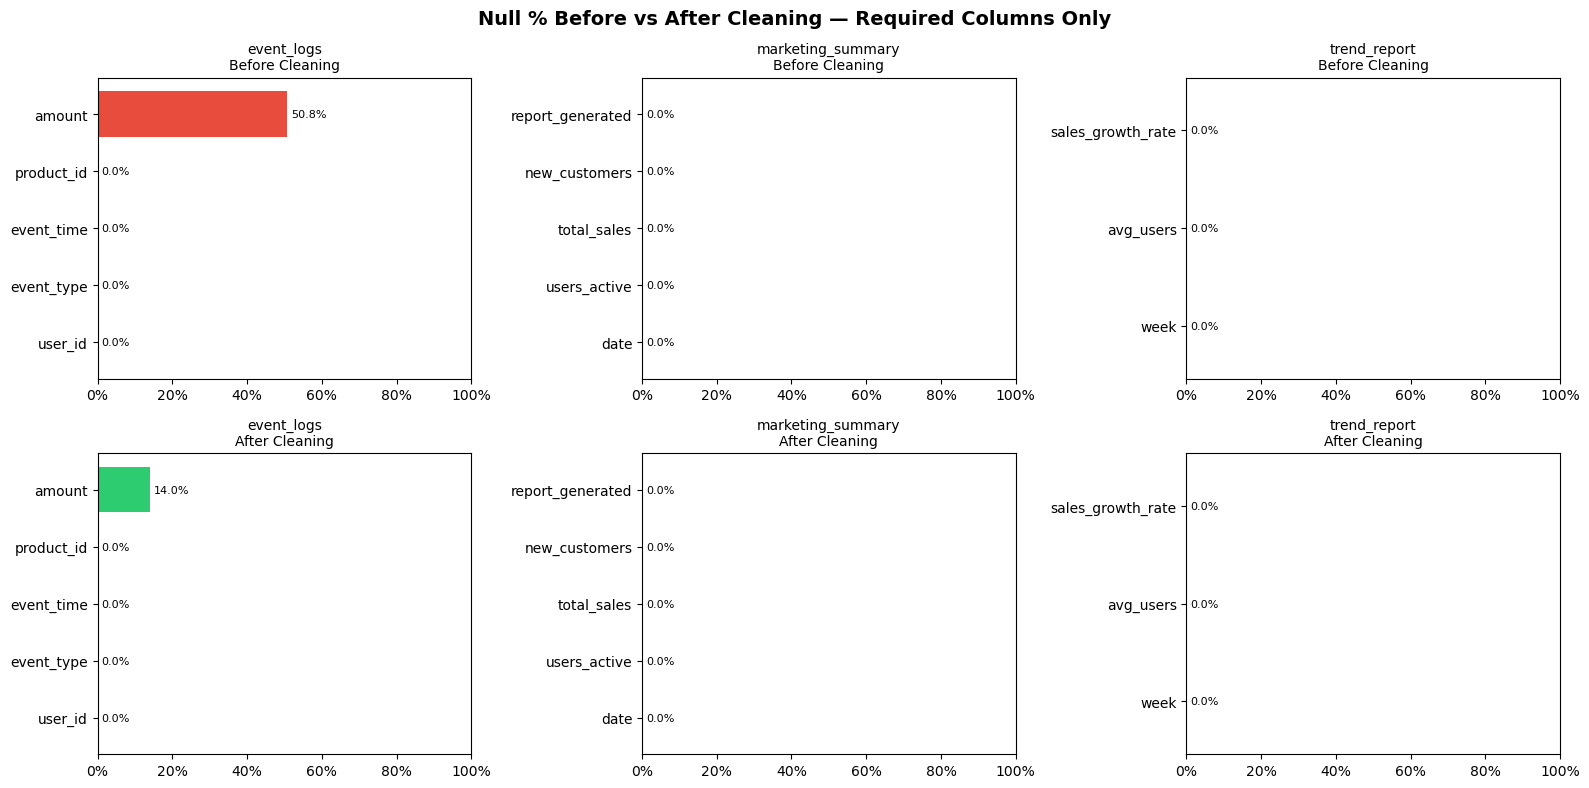

EDA chart saved.


In [72]:
cleaned = {
    'event_logs':        event_logs[['user_id','event_type','event_time','product_id','amount']].isnull().mean() * 100,
    'marketing_summary': marketing_summary[['date','users_active','total_sales','new_customers','report_generated']].isnull().mean() * 100,
    'trend_report':      trend_report[['week','avg_users','sales_growth_rate']].isnull().mean() * 100
}

datasets = ['event_logs', 'marketing_summary', 'trend_report']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Null % Before vs After Cleaning — Required Columns Only', fontsize=14, fontweight='bold')

for col_idx, name in enumerate(datasets):
    for row_idx, (label, data) in enumerate([('Before Cleaning', raw), ('After Cleaning', cleaned)]):
        ax = axes[row_idx][col_idx]
        cols = list(data[name].index)
        vals = list(data[name].values)
        bars = ax.barh(cols, vals, color='#e74c3c' if row_idx == 0 else '#2ecc71')
        ax.set_xlim(0, 100)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_title(f'{name}\n{label}', fontsize=10)
        ax.axvline(x=0, color='black', linewidth=0.5)
        for bar, val in zip(bars, vals):
            ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_null_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA chart saved.")